# Graficos de rangos por productividad

Este notebook sirve para comparar los cuartiles de productividad luego de limpiar los datos e imputarlos.

**Importante**

> Se debe extraer el archivo de tratamientos en los cuartiles de mayor y menor productividad en `.json` 

> Y se debe tener la base de datos en `.csv` después de limpiar e imputar datos

Editar `ROOT_IN` y `ROOT_OUT` para cambiar rutas de entrada y salida.

In [2]:
from dataclasses import dataclass
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

@dataclass
class Config:
    # Cambia estos dos valores para mover todo el flujo de I/O
    ROOT_IN: Path = Path("..")
    ROOT_OUT: Path = Path("..")

    DATA_FILE: str = "BaseDatos/df_imputed_corrected_V2.csv"
    IMPORTANT_VARS_FILE: str = "Resultados/classification_exclude_prod/most_frequent_variables_80.json"
    TREATMENTS_QUARTILES_FILE: str = "Resultados/treatments_quantile_unified.json"
    OUTPUT_SUBDIR: str = "Resultados/classification_exclude_prod"

cfg = Config()
cfg

Config(ROOT_IN=WindowsPath('..'), ROOT_OUT=WindowsPath('..'), DATA_FILE='BaseDatos/df_imputed_corrected_V2.csv', IMPORTANT_VARS_FILE='Resultados/classification_exclude_prod/most_frequent_variables_80.json', TREATMENTS_QUARTILES_FILE='Resultados/treatments_quantile_unified.json', OUTPUT_SUBDIR='Resultados/classification_exclude_prod')

### Verificación de Archivos

In [3]:
data_path = cfg.ROOT_IN / cfg.DATA_FILE
important_vars_path = cfg.ROOT_IN / cfg.IMPORTANT_VARS_FILE
treatments_path = cfg.ROOT_IN / cfg.TREATMENTS_QUARTILES_FILE
output_base = cfg.ROOT_OUT / cfg.OUTPUT_SUBDIR

output_base.mkdir(parents=True, exist_ok=True)

required_files = [data_path, important_vars_path, treatments_path]
missing_files = [str(path) for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Faltan archivos requeridos para ejecutar los graficos:\n" + "\n".join(missing_files)
    )

print("Archivos OK:")
for path in required_files:
    print(f" - {path}")
print(f"Directorio de salida base: {output_base}")

Archivos OK:
 - ..\BaseDatos\df_imputed_corrected_V2.csv
 - ..\Resultados\classification_exclude_prod\most_frequent_variables_80.json
 - ..\Resultados\treatments_quantile_unified.json
Directorio de salida base: ..\Resultados\classification_exclude_prod


### **Limpiar Nombres de Variables**

Algunas librerías no permiten el uso de caracteres, por lo que es necesario reemplazarlos para evitar errores

In [4]:
def clean_feature_names(feature_names):
    cleaned = []
    for name in feature_names:
        cleaned_name = name.replace('[', '(').replace(']', ')').replace('<', '_lt_')
        cleaned.append(cleaned_name)
    return cleaned

df_time_stamp_analysis = pd.read_csv(data_path)
df_time_stamp_analysis.columns = clean_feature_names(df_time_stamp_analysis.columns)

required_columns = {
    "Treatment_Num",
    "Year",
    "Month",
    "Day",
    "Weight of Harvested Fruits (Kg)",
}
missing_columns = sorted(required_columns - set(df_time_stamp_analysis.columns))
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {missing_columns}")

df_time_stamp_analysis["Date"] = pd.to_datetime(
    df_time_stamp_analysis[["Year", "Month", "Day"]],
    errors="coerce",
)
df_time_stamp_analysis = df_time_stamp_analysis.dropna(subset=["Date"]).copy()

print(f"Shape de datos: {df_time_stamp_analysis.shape}")
print(f"Rango de fechas: {df_time_stamp_analysis['Date'].min().date()} -> {df_time_stamp_analysis['Date'].max().date()}")

Shape de datos: (2262, 34)
Rango de fechas: 2024-07-30 -> 2024-12-04


### **Exploración de Fechas Disponibles en dataset**

Se observa el rango de fechas disponible y que las fechas tengan un espacio de una semana

In [ ]:
# Lista de fechas disponibles (maximo 3 lineas)
unique_dates = (
    df_time_stamp_analysis["Date"]
    .dropna()
    .sort_values()
    .dt.date
    .unique()
    .tolist()
 )
print(f"Total fechas: {len(unique_dates)}")
print(f"Rango: {unique_dates[0]} -> {unique_dates[-1]}")
print(unique_dates)

Total fechas: 19
Rango: 2024-07-30 -> 2024-12-04
[datetime.date(2024, 7, 30), datetime.date(2024, 8, 6), datetime.date(2024, 8, 14), datetime.date(2024, 8, 21), datetime.date(2024, 8, 27), datetime.date(2024, 9, 4), datetime.date(2024, 9, 11), datetime.date(2024, 9, 17), datetime.date(2024, 9, 25), datetime.date(2024, 10, 2), datetime.date(2024, 10, 9), datetime.date(2024, 10, 16), datetime.date(2024, 10, 23), datetime.date(2024, 10, 30), datetime.date(2024, 11, 6), datetime.date(2024, 11, 13), datetime.date(2024, 11, 20), datetime.date(2024, 11, 27), datetime.date(2024, 12, 4)]


### **Tratamientos en alta y baja productividad**

Se lee el archivo `.json` para recordar los tratamientos en cuartiles Q1 y Q4 de productividad

In [6]:
with open(important_vars_path, "r", encoding="utf-8") as f:
    important_vars_dict = json.load(f)

with open(treatments_path, "r", encoding="utf-8") as f:
    treatments_quantiles = json.load(f)

if "4" not in treatments_quantiles or "1" not in treatments_quantiles:
    raise KeyError("El JSON de cuartiles debe tener las llaves '4' (alto) y '1' (bajo).")

lista_high = [int(float(t)) for t in treatments_quantiles["4"]]
lista_low = [int(float(t)) for t in treatments_quantiles["1"]]

model_names = ["Nitrogen", "Phosphorus", "Potassium"]
missing_models = [m for m in model_names if m not in important_vars_dict]
if missing_models:
    raise KeyError(f"Faltan modelos en important_vars_dict: {missing_models}")

print(f"Tratamientos high ({len(lista_high)}): {sorted(lista_high)}")
print(f"Tratamientos low ({len(lista_low)}): {sorted(lista_low)}")

Tratamientos high (8): [6, 8, 9, 10, 20, 24, 27, 29]
Tratamientos low (8): [3, 5, 7, 12, 13, 22, 25, 30]


## Frutos Cosechados en el tiempo (Tratamientos Q1 vs Q4)

Peor tratamiento (lista_low, menor indice): 3
Mejor tratamiento (lista_high, mayor indice): 29
Acumulado final peor tratamiento: 20.62
Acumulado final mejor tratamiento: 27.47


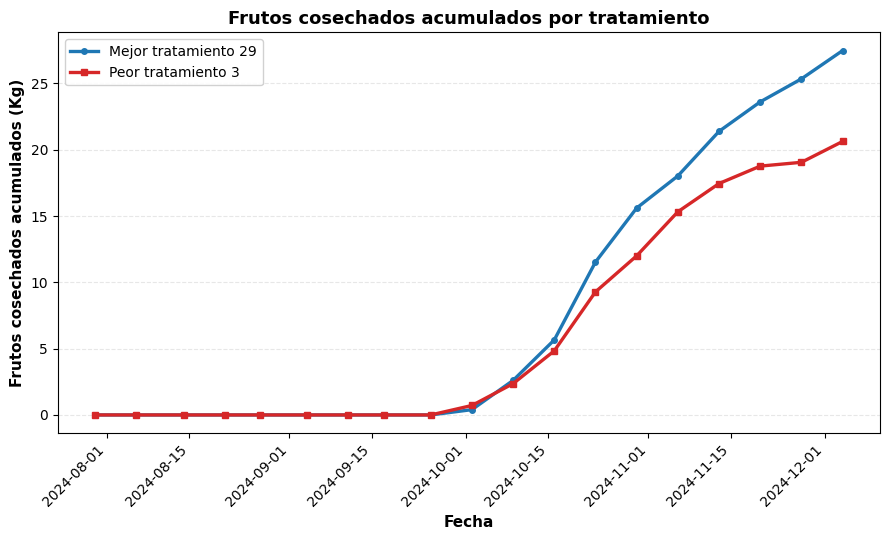

In [ ]:
# Grafica acumulativa para mejor y peor tratamiento segun frutos cosechados
fruits_var = "Weight of Harvested Fruits (Kg)"
required_cols = {"Treatment_Num", "Date", fruits_var}
missing_cols = sorted(required_cols - set(df_time_stamp_analysis.columns))
if missing_cols:
    raise ValueError(f"Faltan columnas requeridas para la grafica acumulativa: {missing_cols}")

if not lista_high or not lista_low:
    raise ValueError("Las listas lista_high o lista_low estan vacias.")

# Suma por fecha y tratamiento (hay varios registros por fecha)
daily_fruits = (
    df_time_stamp_analysis
    .groupby(["Treatment_Num", "Date"], as_index=False)[fruits_var]
    .sum()
    .sort_values(["Treatment_Num", "Date"])
)

# Mejor y peor tratamiento tomando los indices solicitados
best_treatment = max(lista_high)
worst_treatment = min(lista_low)

def build_cumulative(df_daily, treatment_num, value_col):
    subset = df_daily[df_daily["Treatment_Num"] == treatment_num].copy()
    subset = subset.sort_values("Date")
    subset["Cumulative"] = subset[value_col].cumsum()
    return subset
# Filtrar datasets en base a los grupos de tratamientos seleccionados
best_df = build_cumulative(daily_fruits, best_treatment, fruits_var)
worst_df = build_cumulative(daily_fruits, worst_treatment, fruits_var)

if best_df.empty or worst_df.empty:
    raise ValueError("No hay datos para los tratamientos seleccionados.")

# Mejor y peor tratamiento
best_final = float(best_df["Cumulative"].iloc[-1])
worst_final = float(worst_df["Cumulative"].iloc[-1])

print(f"Peor tratamiento (lista_low, menor indice): {worst_treatment}")
print(f"Mejor tratamiento (lista_high, mayor indice): {best_treatment}")
print(f"Acumulado final peor tratamiento: {worst_final:.2f}")
print(f"Acumulado final mejor tratamiento: {best_final:.2f}")

fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
ax.plot(
    best_df["Date"],
    best_df["Cumulative"],
    color="#1f77b4",
    linewidth=2.4,
    marker="o",
    markersize=4,
    label=f"Mejor tratamiento {best_treatment}",
)
ax.plot(
    worst_df["Date"],
    worst_df["Cumulative"],
    color="#d62728",
    linewidth=2.4,
    marker="s",
    markersize=4,
    label=f"Peor tratamiento {worst_treatment}",
)

ax.set_title("Frutos cosechados acumulados por tratamiento", fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha", fontsize=11, fontweight="bold")
ax.set_ylabel("Frutos cosechados acumulados (Kg)", fontsize=11, fontweight="bold")
ax.legend(loc="best", framealpha=0.9)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
def compare_productivity_ranges(df, vars_to_plot, var_productivity, lista_treats_high, lista_treats_low, path):
    '''
    Esta funcion realiza el grafico de las variables seleccionadas para los tratamientos de alta y baja productividad, mostrando la media y desviacion estandar por fecha.

    args:
        df: DataFrame con los datos.
        vars_to_plot: Lista de variables a graficar.
        var_productivity: Nombre de la variable de productividad (ej. "Weight of Harvested Fruits (Kg)").
        lista_treats_high: Lista de tratamientos de alta productividad.
        lista_treats_low: Lista de tratamientos de baja productividad.
        path: Ruta donde se guardarán las imágenes.

    '''
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)

    color_high = "#D81532CA" 
    color_low = "#0F5CC0BE"   
    generated = 0
    # Iterar las variables
    for var in vars_to_plot:
        if var not in df.columns:
            print(f"[SKIP] Columna no encontrada: {var}")
            continue
        # Filtrar los datos para los tratamientos de alta y baja productividad
        df_high = df[df["Treatment_Num"].isin(lista_treats_high)].copy()
        df_low = df[df["Treatment_Num"].isin(lista_treats_low)].copy()

        if df_high.empty or df_low.empty:
            print(f"[SKIP] Sin datos suficientes para {var}")
            continue
        # Calcular media y desviación estándar agrupando por fecha
        stats_high = df_high.groupby("Date").agg({var: ["mean", "std"]}).reset_index()
        stats_low = df_low.groupby("Date").agg({var: ["mean", "std"]}).reset_index()

        # Renombrar columnas para mayor claridad
        stats_high.columns = ["Date", f"{var}_mean", f"{var}_std"]
        stats_low.columns = ["Date", f"{var}_mean", f"{var}_std"]

        stats_high.fillna(0, inplace=True)
        stats_low.fillna(0, inplace=True)

        y_max = max(
            (stats_high[f"{var}_mean"] + stats_high[f"{var}_std"]).max(),
            (stats_low[f"{var}_mean"] + stats_low[f"{var}_std"]).max(),
        )

        fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

        ax1.plot(
            stats_high["Date"],
            stats_high[f"{var}_mean"],
            color=color_high,
            linewidth=2.5,
            label="High Productivity",
            marker="o",
            markersize=5,
        )
        # Realizar grafico de la media con la desviación estándar como área sombreada
        ax1.fill_between(
            stats_high["Date"],
            stats_high[f"{var}_mean"] - stats_high[f"{var}_std"],
            stats_high[f"{var}_mean"] + stats_high[f"{var}_std"],
            color=color_high,
            alpha=0.3,
        )

        ax1.plot(
            stats_low["Date"],
            stats_low[f"{var}_mean"],
            color=color_low,
            linewidth=2.5,
            label="Low Productivity",
            marker="s",
            markersize=5,
        )
        ax1.fill_between(
            stats_low["Date"],
            stats_low[f"{var}_mean"] - stats_low[f"{var}_std"],
            stats_low[f"{var}_mean"] + stats_low[f"{var}_std"],
            color=color_low,
            alpha=0.3,
        )

        ax1.set_xlabel("Week", fontsize=12, fontweight="bold")
        ax1.set_ylabel(var.replace("_", " "), fontsize=12, fontweight="bold")
        #ax1.set_title(
        #    f"{var.replace('_', ' ')} - Comparison by Productivity Level",
        #    fontsize=14,
        #    fontweight="bold",
        #)
        ax1.legend(loc="best", fontsize=11, framealpha=0.9)

        # Etiquetas del eje X personalizadas de -9 a 9
        x_labels = list(range(-9, 10))
        combined_dates = (
            pd.Index(stats_high["Date"])
            .union(pd.Index(stats_low["Date"]))
            .sort_values()
        )
    
        if len(combined_dates) > 0:
            tick_idx = np.linspace(0, len(combined_dates) - 1, len(x_labels)).round().astype(int)
            x_ticks = pd.DatetimeIndex(combined_dates[tick_idx])
            ax1.set_xticks(x_ticks)
            ax1.set_xticklabels([str(v) for v in x_labels])

        ax1.grid(axis="x", which="major", alpha=0.3, linestyle="--")
        ax1.grid(axis="y", which="major", alpha=0.3, linestyle="--")
    
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
        # Agregar líneas verticales y anotaciones para eventos importantes
        fecha_referencia = pd.to_datetime("2024-10-02")
        ax1.axvline(x=fecha_referencia, color="darkred", linestyle="--", linewidth=1.5, alpha=0.8, zorder=5)
        ax1.annotate(
            "Harvest & senescence",
            xy=(fecha_referencia, y_max),
            xytext=(10, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            arrowprops=dict(arrowstyle="->", color="darkred", lw=1.2),
            color="darkred",
        )

        fecha_referencia = pd.to_datetime("2024-08-21")
        ax1.axvline(x=fecha_referencia, color="black", linestyle="dashdot", linewidth=1.5, alpha=0.8, zorder=5)
        ax1.annotate(
            "Fruit set & flowering",
            xy=(fecha_referencia, y_max * 0.9),
            xytext=(10, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
            color="black",
        )

        plt.tight_layout()
        # Guardar las figuras en formato PNG y SVG
        safe_var = var.replace(" ", "_").replace("/", "_")
        safe_prod = var_productivity.replace(" ", "_").replace("/", "_")
        filename_png = path / f"comparison_{safe_var}_{safe_prod}.png"
        filename_svg = path / f"comparison_{safe_var}_{safe_prod}.svg"

        plt.savefig(filename_png, dpi=300, bbox_inches="tight")
        plt.savefig(filename_svg, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        generated += 1

    return generated

In [ ]:
# Fecha variable por variable
early_detection_dates = {
    # Ejemplo:
    # "Some Variable": "2024-09-05",
}

def compare_productivity_ranges_with_alert(
    df, vars_to_plot, var_productivity, lista_treats_high, lista_treats_low, path, 
    alert_dates_map, alert_label="early detection alert", alert_color="purple", alert_linestyle=":", alert_linewidth=1.6,  alert_alpha=0.85, alert_y_ratio=0.8, alert_x_offset=10,
    alert_y_offset=0, alert_arrowprops=None, alert_text_kwargs=None,  keep_existing_refs=True,  **kwargs,
):
    """
    Esta funcion realiza el grafico de las variables seleccionadas para los tratamientos de alta y baja productividad, mostrando la media y desviacion estandar por fecha.

    Args:
        df: DataFrame con los datos.
        vars_to_plot: Lista de variables a graficar.
        var_productivity: Nombre de la variable de productividad (ej. "Weight of Harvested Fruits (Kg)").
        lista_treats_high: Lista de tratamientos de alta productividad.
        lista_treats_low: Lista de tratamientos de baja productividad.
        path: Ruta donde se guardarán las imágenes.
        alert_dates_map: Diccionario con fechas de alerta por variable.
        alert_label: Etiqueta para las alertas tempranas.
        alert_color: Color de la línea de alerta.
        alert_linestyle: Estilo de línea para la alerta.
        alert_linewidth: Ancho de línea para la alerta.
        alert_alpha: Transparencia de la línea de alerta.
        alert_y_ratio: Posición vertical de la anotación de alerta como proporción del valor máximo.
        alert_x_offset: Desplazamiento horizontal de la anotación de alerta.
        alert_y_offset: Desplazamiento vertical de la anotación de alerta.
        keep_existing_refs: Booleano para mantener referencias existentes (como cosecha y floración).


    """
    def _maybe_add_vline(
        ax, date_value, label, y_pos, color, linestyle, linewidth, alpha, x_offset, y_offset, arrowprops, text_kwargs,
    ):
        '''
        Realiza una línea vertical y una anotación en el gráfico si se ingresa una fecha válida.
        Se usa para anotar la fecha de alerta temprana para cada variable, si existe.

        Args:
            ax: Eje del gráfico donde se dibujará la línea y la anotación.
            date_value: Fecha de la alerta temprana (puede ser None).
            label: Etiqueta para la anotación.
            y_pos: Posición vertical de la anotación.
            color: Color de la línea y la anotación.
            linestyle: Estilo de línea para la línea vertical.
            linewidth: Ancho de línea para la línea vertical.
            alpha: Transparencia de la línea vertical.
            x_offset: Desplazamiento horizontal de la anotación.
            y_offset: Desplazamiento vertical de la anotación.
            arrowprops: Propiedades de la flecha para la anotación.
            text_kwargs: Diccionario de argumentos adicionales para la anotación de texto.
    
        '''
        if date_value is None:
            return
        # Convertir la fecha a un objeto datetime, si es posible
        date_value = pd.to_datetime(date_value, errors="coerce")
        if pd.isna(date_value):
            return
        ax.axvline(
            x=date_value, color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, zorder=6,
        )

        ax.annotate(
            label, xy=(date_value, y_pos), xytext=(x_offset, y_offset), textcoords="offset points", ha="left", va="center", arrowprops=arrowprops,
            color=color, **(text_kwargs or {}),
        )

    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)

    color_high = "#D81532CA"
    color_low = "#0F5CC0BE"
    generated = 0

    # Iterar las variables
    for var in vars_to_plot:
        if var not in df.columns:
            print(f"[SKIP] Columna no encontrada: {var}")
            continue
        # Filtrar los datos para los tratamientos de alta y baja productividad                
        df_high = df[df["Treatment_Num"].isin(lista_treats_high)].copy()
        df_low = df[df["Treatment_Num"].isin(lista_treats_low)].copy()

        if df_high.empty or df_low.empty:
            print(f"[SKIP] Sin datos suficientes para {var}")
            continue
        # Calcular media y desviación estándar agrupando por fecha
        stats_high = df_high.groupby("Date").agg({var: ["mean", "std"]}).reset_index()
        stats_low = df_low.groupby("Date").agg({var: ["mean", "std"]}).reset_index()
        # Renombrar columnas para mayor claridad
        stats_high.columns = ["Date", f"{var}_mean", f"{var}_std"]
        stats_low.columns = ["Date", f"{var}_mean", f"{var}_std"]

        stats_high.fillna(0, inplace=True)
        stats_low.fillna(0, inplace=True)

        # Calcular el valor máximo para establecer límites en el eje Y
        y_max = max(
            (stats_high[f"{var}_mean"] + stats_high[f"{var}_std"]).max(),
            (stats_low[f"{var}_mean"] + stats_low[f"{var}_std"]).max(),
        )

        fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

        ax1.plot(
            stats_high["Date"],
            stats_high[f"{var}_mean"],
            color=color_high,
            linewidth=2.5,
            label="High Productivity",
            marker="o",
            markersize=5,
        )
        # Realizar grafico de la media con la desviación estándar como área sombreada
        ax1.fill_between(
            stats_high["Date"],
            stats_high[f"{var}_mean"] - stats_high[f"{var}_std"],
            stats_high[f"{var}_mean"] + stats_high[f"{var}_std"],
            color=color_high,
            alpha=0.3,
        )

        ax1.plot(
            stats_low["Date"],
            stats_low[f"{var}_mean"],
            color=color_low,
            linewidth=2.5,
            label="Low Productivity",
            marker="s",
            markersize=5,
        )
        ax1.fill_between(
            stats_low["Date"],
            stats_low[f"{var}_mean"] - stats_low[f"{var}_std"],
            stats_low[f"{var}_mean"] + stats_low[f"{var}_std"],
            color=color_low,
            alpha=0.3,
        )

        ax1.set_xlabel("Week", fontsize=12, fontweight="bold")
        ax1.set_ylabel(var.replace("_", " "), fontsize=12, fontweight="bold")
        ax1.legend(loc="best", fontsize=11, framealpha=0.9)
        # NOTE: Etiquetas del eje X personalizadas de -9 a 9 ya que estos son los numeros de semanas
        x_labels = list(range(-9, 10))
        combined_dates = (
            pd.Index(stats_high["Date"])
            .union(pd.Index(stats_low["Date"]))
            .sort_values()
        )
        # Establecer las etiquetas del eje X
        if len(combined_dates) > 0:
            tick_idx = np.linspace(0, len(combined_dates) - 1, len(x_labels)).round().astype(int)
            x_ticks = pd.DatetimeIndex(combined_dates[tick_idx])
            ax1.set_xticks(x_ticks)
            ax1.set_xticklabels([str(v) for v in x_labels])
        
        ax1.grid(axis="x", which="major", alpha=0.3, linestyle="--")
        ax1.grid(axis="y", which="major", alpha=0.3, linestyle="--")
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

        if keep_existing_refs:
            # Agregar líneas verticales y anotaciones para eventos importantes
            fecha_referencia = pd.to_datetime("2024-10-02")
            ax1.axvline(x=fecha_referencia, color="darkred", linestyle="--", linewidth=1.5, alpha=0.8, zorder=5)
            ax1.annotate(
                "Harvest & senescence",
                xy=(fecha_referencia, y_max),
                xytext=(10, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                arrowprops=dict(arrowstyle="->", color="darkred", lw=1.2),
                color="darkred",
            )

            fecha_referencia = pd.to_datetime("2024-08-21")
            ax1.axvline(x=fecha_referencia, color="black", linestyle="dashdot", linewidth=1.5, alpha=0.8, zorder=5)
            ax1.annotate(
                "Fruit set & flowering",
                xy=(fecha_referencia, y_max * 0.9),
                xytext=(10, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
                color="black",
            )

        # Graficar linea vertical para la alerta temprana si existe una fecha asociada a la variable
        alert_date = alert_dates_map.get(var)
        default_arrowprops = dict(arrowstyle="->", color=alert_color, lw=1.2)
        _maybe_add_vline(
            ax=ax1, date_value=alert_date, label=alert_label, y_pos=y_max * alert_y_ratio, color=alert_color, linestyle=alert_linestyle, linewidth=alert_linewidth,
            alpha=alert_alpha, x_offset=alert_x_offset, y_offset=alert_y_offset, arrowprops=alert_arrowprops or default_arrowprops, text_kwargs=alert_text_kwargs,
        )

        plt.tight_layout()

        # Guardar las figuras en formato PNG y SVG
        safe_var = var.replace(" ", "_").replace("/", "_")
        safe_prod = var_productivity.replace(" ", "_").replace("/", "_")
        filename_png = path / f"comparison_{safe_var}_{safe_prod}.png"
        filename_svg = path / f"comparison_{safe_var}_{safe_prod}.svg"

        plt.savefig(filename_png, dpi=300, bbox_inches="tight")
        plt.savefig(filename_svg, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        generated += 1

    return generated

### Mapear Semanas a rango -9 a 9 para el gráfico

In [ ]:
# mapa de numero de semana a fecha
unique_dates = (
    df_time_stamp_analysis["Date"]
    .dropna()
    .sort_values()
    .dt.date
    .unique()
    .tolist()
 )

# pasar a string "unique_dates" 
unique_dates_str = [str(date) for date in unique_dates]


**Importante**

En este caso son 19 semanas en total
El enumerado de semanas va desde -9 hasta 9

In [11]:
# generar lista desde -9 hasta 9
lista_week_conversion = list(range(-9, 10))

# Generar diccionario de conversion de semana a fecha
week_to_date_map = dict(zip(lista_week_conversion, unique_dates_str))

In [12]:
week_to_date_map

{-9: '2024-07-30',
 -8: '2024-08-06',
 -7: '2024-08-14',
 -6: '2024-08-21',
 -5: '2024-08-27',
 -4: '2024-09-04',
 -3: '2024-09-11',
 -2: '2024-09-17',
 -1: '2024-09-25',
 0: '2024-10-02',
 1: '2024-10-09',
 2: '2024-10-16',
 3: '2024-10-23',
 4: '2024-10-30',
 5: '2024-11-06',
 6: '2024-11-13',
 7: '2024-11-20',
 8: '2024-11-27',
 9: '2024-12-04'}

In [13]:
df_time_stamp_analysis

,Plant_Height (cm),Chlorophyll (SPAD),Number of Flowers,Number of Harvested Fruits,Weight of Harvested Fruits (Kg),Fruit Height (mm),Sap pH,Sap K (ppm),Sap Ca (ppm),Sap Na (ppm),...,7in1_Conductivity(mS/cm),Pynamometer_Radiation(W/m2),Nitrogen,Phosphorus,Potassium,Year,Month,Day,Treatment_Num,Date
0,21.50,34.80,13.0,0.0,0.000,0.0,5.5000,3455.0,748.5,49.05,...,0.1830,428.0,2.0,2.0,2.0,2024.0,7.0,30.0,27.0,2024-07-30
1,22.00,37.50,9.9,0.0,0.000,0.0,5.4860,3055.0,364.1,48.65,...,0.3090,295.0,2.0,1.0,1.0,2024.0,7.0,30.0,24.0,2024-07-30
2,18.00,37.20,15.2,0.0,0.000,0.0,5.5880,3170.0,283.6,42.40,...,0.1180,383.0,0.0,0.0,1.0,2024.0,7.0,30.0,4.0,2024-07-30
3,18.50,39.50,13.6,0.0,0.000,0.0,5.4345,3260.0,217.4,57.50,...,0.2780,464.0,1.0,1.0,1.0,2024.0,7.0,30.0,15.0,2024-07-30
4,22.00,40.10,10.9,0.0,0.000,0.0,5.8920,3080.0,326.0,50.20,...,0.3710,508.0,0.0,2.0,2.0,2024.0,7.0,30.0,9.0,2024-07-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2257,168.05,57.72,20.1,1.0,0.180,70.3,5.6190,3880.0,383.3,55.20,...,0.0940,153.9,2.0,2.0,2.0,2024.0,12.0,4.0,27.0,2024-12-04
2258,152.80,56.59,20.3,7.0,0.706,60.7,5.5580,3200.0,410.0,47.45,...,0.2157,290.5,2.0,2.0,2.0,2024.0,12.0,4.0,27.0,2024-12-04
2259,151.50,61.13,16.9,6.0,0.829,70.2,5.5040,3430.0,219.0,54.80,...,0.0280,269.0,0.0,0.0,1.0,2024.0,12.0,4.0,4.0,2024-12-04
2260,82.60,46.24,15.7,2.0,0.174,50.7,5.6290,3390.0,213.6,54.60,...,0.2627,721.3,0.0,0.0,1.0,2024.0,12.0,4.0,4.0,2024-12-04


## Gráfico Final y Guardar archivos

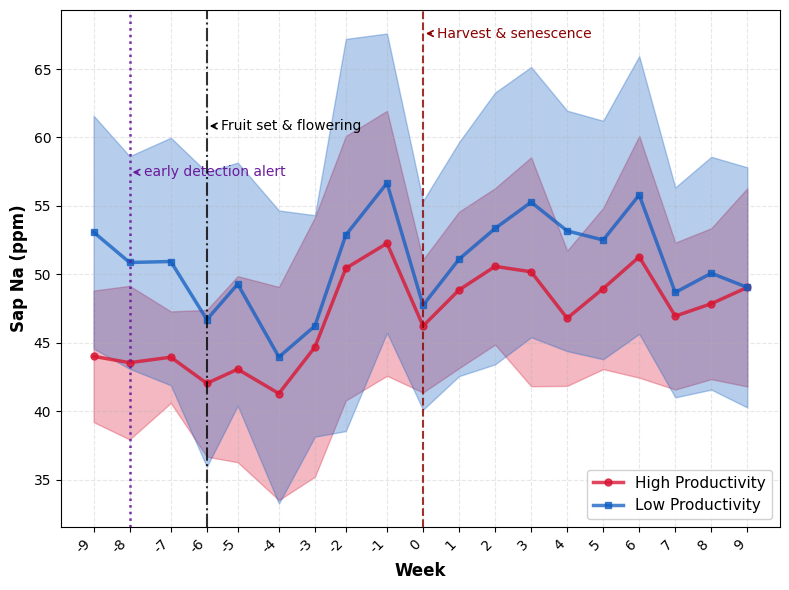

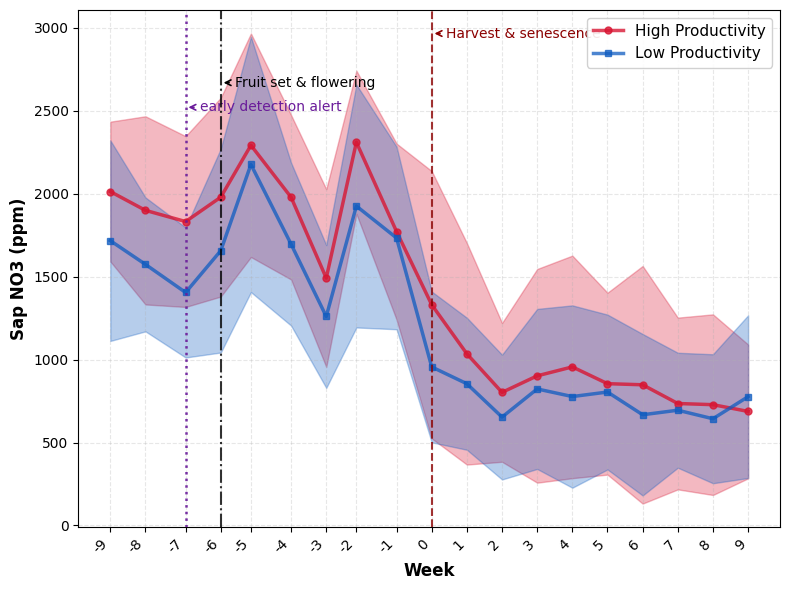

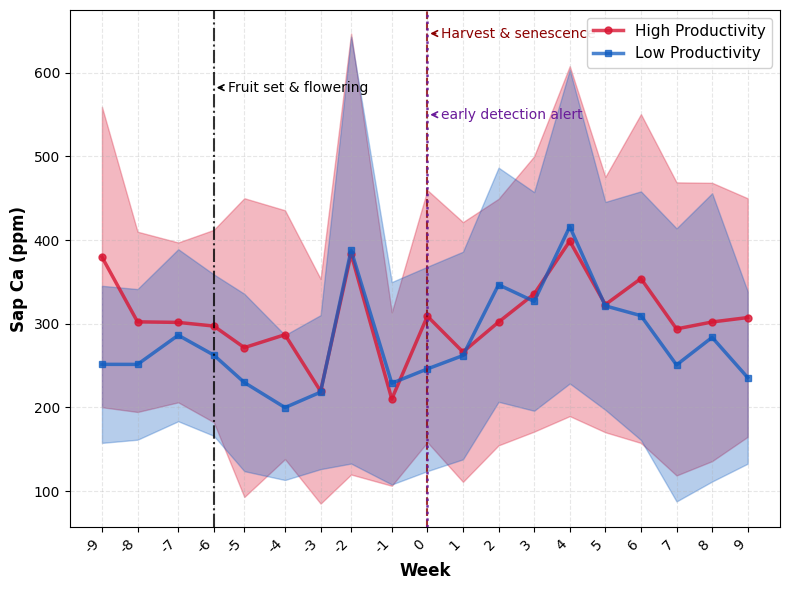

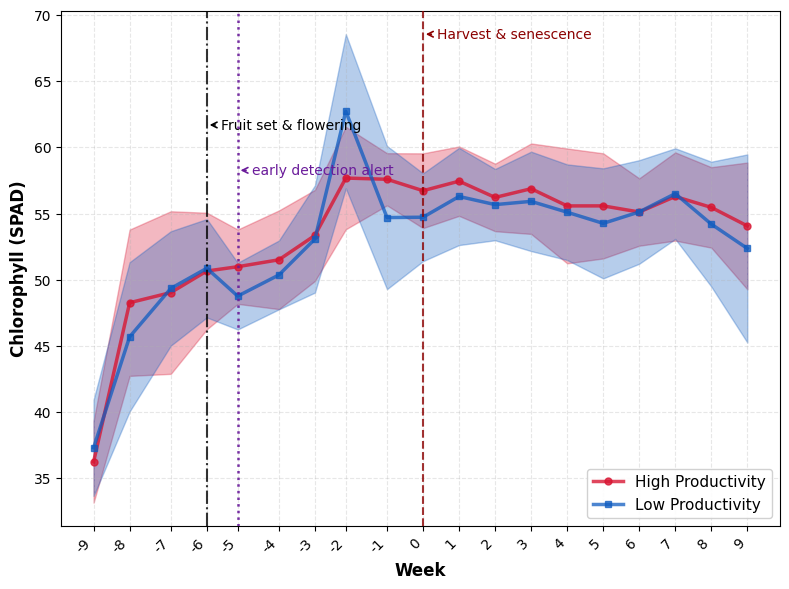

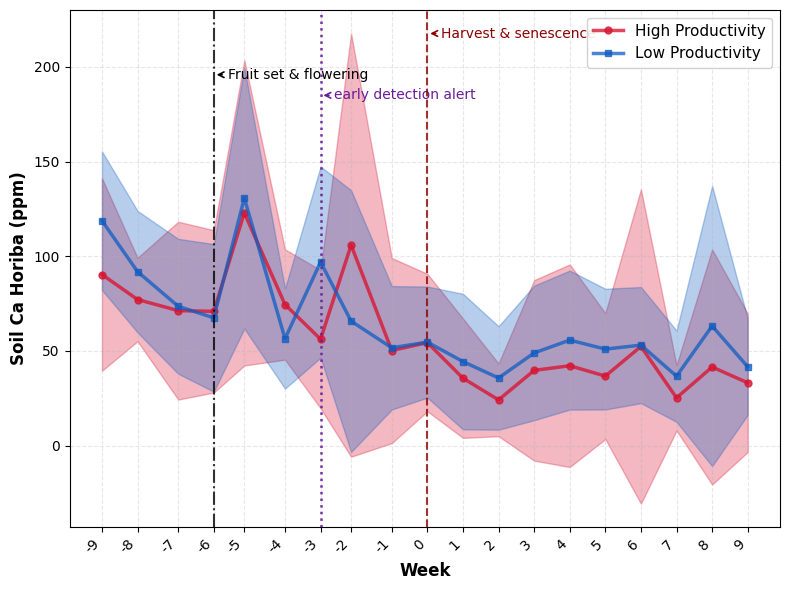

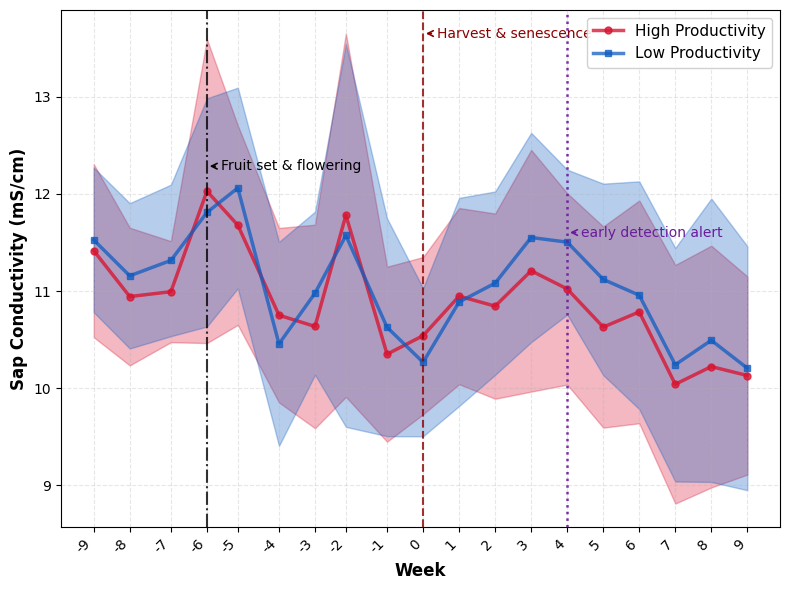

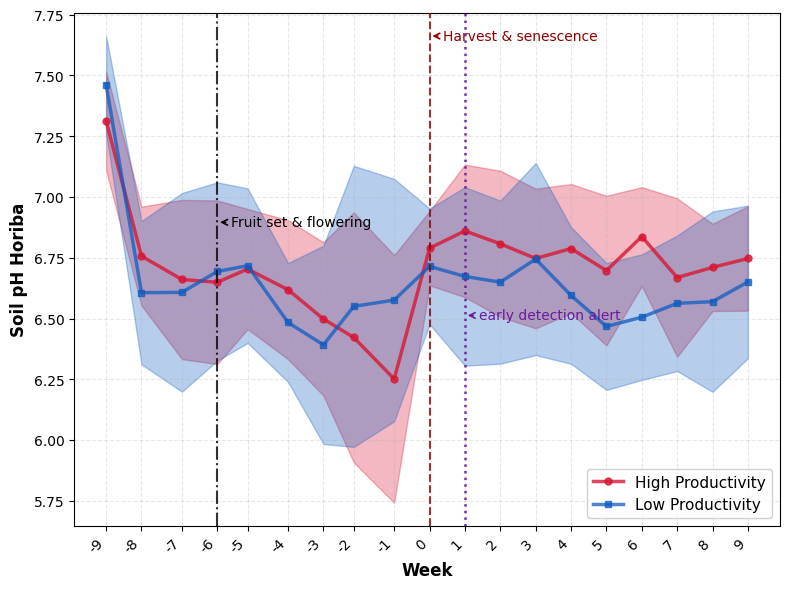

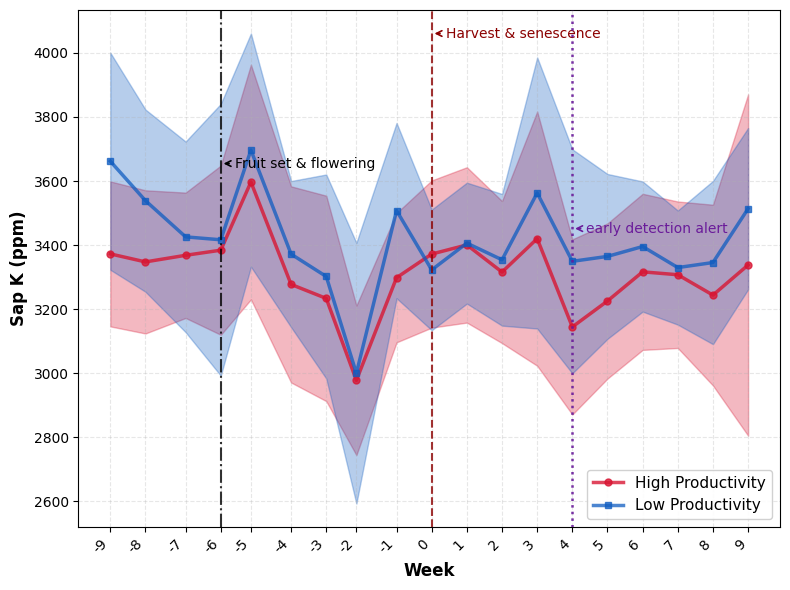

Graficos generados: 8
Salida: ..\Resultados\classification_exclude_prod\Productivity_Comparison_EarlyDetection


In [14]:
# Graficas con fechas especificas por variable (early detection alert)
early_detection_dates = {
    "Sap Na (ppm)": "2024-08-06",
    "Sap NO3 (ppm)": "2024-08-14",
    "Sap Ca (ppm)": "2024-10-02",
    "Chlorophyll (SPAD)": "2024-08-27",
    "Soil Ca Horiba (ppm)": "2024-09-11",
    "Sap Conductivity (mS/cm)": week_to_date_map[4],
    "Soil pH Horiba": week_to_date_map[1],
    "Sap K (ppm)": week_to_date_map[4]
}

vars_to_plot_custom = list(early_detection_dates.keys())
out_dir_custom = output_base / "Productivity_Comparison_EarlyDetection"

generated_custom = compare_productivity_ranges_with_alert(
    df=df_time_stamp_analysis,
    vars_to_plot=vars_to_plot_custom,
    var_productivity="Weight of Harvested Fruits (Kg)",
    lista_treats_high=lista_high,
    lista_treats_low=lista_low,
    path=out_dir_custom,
    alert_dates_map=early_detection_dates,
    alert_label="early detection alert",
    alert_color="#6A1B9A",
    alert_linestyle=":",
    alert_linewidth=1.8,
    alert_alpha=0.9,
    alert_y_ratio=0.85,
    alert_x_offset=10,
    alert_y_offset=0,
    alert_arrowprops=None,
    alert_text_kwargs=None,
    keep_existing_refs=True,
)

print(f"Graficos generados: {generated_custom}")
print(f"Salida: {out_dir_custom}")

In [7]:
model_names

['Nitrogen', 'Phosphorus', 'Potassium']

In [ ]:
var_productivity = "Weight of Harvested Fruits (Kg)"
total_generated = 0

for model_name in model_names:
    selected_vars = important_vars_dict[model_name][:10]
    out_dir = output_base / f"Productivity_Comparison_{model_name}"

    generated = compare_productivity_ranges(
        df=df_time_stamp_analysis,
        vars_to_plot=selected_vars,
        var_productivity=var_productivity,
        lista_treats_high=lista_high,
        lista_treats_low=lista_low,
        path=out_dir,
    )

    total_generated += generated
    print(f"{model_name}: {generated} graficos generados en {out_dir}")

print(f"Total de graficos generados: {total_generated}")